# Support Vector Machine (SVM) Model

Train and evaluate a Support Vector Machine classifier, run hyperparameter tuning with GridSearchCV, and plot the confusion matrix.

In [1]:
# Check if running in Google Colab and set up environment cleanly
import os
import shutil
from pathlib import Path

if 'COLAB_RELEASE_TAG' in os.environ:
    # 1. Force change directory back to the root '/content'
    os.chdir('/content')

    # 2. Clean up any accidental nested clone directories to save space and resolve path confusion
    nested_path = Path('/content/Bird-Species-Classification-ML/Bird-Species-Classification-ML')
    if nested_path.exists():
        print("Cleaning up accidental nested git clone folders...")
        shutil.rmtree(nested_path, ignore_errors=True)

    # 3. Clone repository if it doesn't exist under /content
    if not os.path.exists('Bird-Species-Classification-ML'):
        print("Cloning Bird-Species-Classification-ML repository...")
        !git clone https://github.com/01329582993/Bird-Species-Classification-ML.git

    # 4. Change working directory to '/content/Bird-Species-Classification-ML'
    %cd /content/Bird-Species-Classification-ML
else:
    print("Running locally. Working directory:", os.getcwd())

Cloning Bird-Species-Classification-ML repository...
Cloning into 'Bird-Species-Classification-ML'...
remote: Enumerating objects: 252, done.
remote: Counting objects: 100% (113/113), done.
remote: Compressing objects: 100% (84/84), done.
remote: Total 252 (delta 76), reused 45 (delta 29), pack-reused 139 (from 1)
Receiving objects: 100% (252/252), 6.99 MiB | 11.33 MiB/s, done.
Resolving deltas: 100% (154/154), done.
/content/Bird-Species-Classification-ML


In [2]:
# Load pre-computed features and labels
# If features are missing, automatically download the dataset and run extraction
import os
import sys
import shutil
import numpy as np
import joblib
from pathlib import Path

DATA_DIR = Path("./processed_data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
npz_file = DATA_DIR / "combined_hog_color_lbp.npz"

if not npz_file.exists():
    print("Feature files not found. Running automatic feature extraction pipeline...")
    import pandas as pd
    import kagglehub
    from tqdm.auto import tqdm
    from PIL import Image
    from skimage.feature import hog, local_binary_pattern

    # ---- Step 1: Download and prepare dataset ----
    def locate_metadata():
        for p in [Path("metadata_preprocessed.csv"), DATA_DIR / "metadata_preprocessed.csv"]:
            if p.exists():
                return p
        return None

    metadata_file = locate_metadata()
    dataset_preprocessed_dir = Path("dataset_20_species_preprocessed")

    if metadata_file is None or not dataset_preprocessed_dir.exists():
        print("  Downloading CUB-200-2011 dataset via Kaggle Hub...")
        download_path = Path(kagglehub.dataset_download("wenewone/cub2002011"))
        DATASET_ROOT = download_path / "CUB_200_2011"
        IMAGES_FOLDER = DATASET_ROOT / "images"

        SUBSET_DIR = Path("./dataset_20_species")
        if SUBSET_DIR.exists():
            shutil.rmtree(SUBSET_DIR)
        SUBSET_DIR.mkdir(parents=True, exist_ok=True)

        bd_keywords = [
            'Crow', 'Kingfisher', 'Hummingbird', 'Mallard', 'Warbler',
            'Towhee', 'Jay', 'Creeper', 'Waxwing', 'Cuckoo',
            'Thrush', 'Woodpecker', 'Wren', 'Vireo', 'Catbird',
            'Meadowlark', 'Blackbird', 'Gull', 'Tern', 'Pelican'
        ]
        species_folders = sorted([f for f in IMAGES_FOLDER.iterdir() if f.is_dir()])
        selected_species = []
        for folder in species_folders:
            if any(kw.lower() in folder.name.lower() for kw in bd_keywords):
                if folder not in selected_species:
                    selected_species.append(folder)
            if len(selected_species) == 20:
                break

        for species_path in selected_species:
            shutil.copytree(str(species_path), SUBSET_DIR / species_path.name)

        classes_df = pd.read_csv(DATASET_ROOT / "classes.txt", sep=r"\s+", names=["class_id", "class_name"])
        images_df = pd.read_csv(DATASET_ROOT / "images.txt", sep=r"\s+", names=["image_id", "image_path"])
        labels_df = pd.read_csv(DATASET_ROOT / "image_class_labels.txt", sep=r"\s+", names=["image_id", "class_id"])

        selected_names = [p.name for p in selected_species]
        dataset_info = images_df.merge(labels_df, on="image_id").merge(classes_df, on="class_id")
        dataset_info = dataset_info[dataset_info["class_name"].isin(selected_names)].copy().reset_index(drop=True)
        dataset_info["full_image_path"] = dataset_info["image_path"].apply(lambda p: SUBSET_DIR / p)

        sys.path.append(str(Path(".").resolve()))
        from src.preprocessing import create_stratified_splits, preprocess_and_save_image

        split_metadata = create_stratified_splits(dataset_info, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, random_state=42)

        if dataset_preprocessed_dir.exists():
            shutil.rmtree(dataset_preprocessed_dir)
        dataset_preprocessed_dir.mkdir(parents=True, exist_ok=True)

        preprocessed_paths = []
        for idx, row in split_metadata.iterrows():
            dst_file = dataset_preprocessed_dir / Path(row["image_path"])
            preprocess_and_save_image(row["full_image_path"], dst_file, target_size=(224, 224))
            preprocessed_paths.append(str(dst_file))
        split_metadata["preprocessed_image_path"] = preprocessed_paths
        cols = ["image_id", "image_path", "class_id", "class_name", "split", "preprocessed_image_path"]
        split_metadata[cols].to_csv("metadata_preprocessed.csv", index=False)
        split_metadata[cols].to_csv(DATA_DIR / "metadata_preprocessed.csv", index=False)
        metadata_file = Path("metadata_preprocessed.csv")
        print("  Dataset preparation complete!")

    # ---- Step 2: Extract features ----
    def _extract_hog(img_path):
        img = Image.open(img_path).convert("L").resize((128, 128), Image.Resampling.LANCZOS)
        return hog(np.array(img), orientations=9, pixels_per_cell=(8,8),
                   cells_per_block=(2,2), block_norm='L2-Hys', visualize=False).astype(np.float32)

    def _extract_color(img_path):
        img_arr = np.array(Image.open(img_path).convert("RGB"))
        hists = []
        for ch in range(3):
            h, _ = np.histogram(img_arr[:,:,ch], bins=32, range=(0,256))
            h = h.astype(np.float32); h /= (h.sum() + 1e-9)
            hists.append(h)
        return np.concatenate(hists)

    def _extract_lbp(img_path):
        img_arr = np.array(Image.open(img_path).convert("L"), dtype=np.uint8)
        lbp = local_binary_pattern(img_arr, P=8, R=1, method="uniform")
        h, _ = np.histogram(lbp.ravel(), bins=np.arange(0,11), range=(0,10))
        h = h.astype(np.float32); h /= (h.sum() + 1e-9)
        return h

    metadata_df = pd.read_csv(locate_metadata())
    X_hog, X_color, X_lbp, y_all, splits_all = [], [], [], [], []

    print("  Extracting HOG + Color Histogram + LBP features...")
    for _, row in tqdm(metadata_df.iterrows(), total=len(metadata_df)):
        img_path = Path(row["preprocessed_image_path"])
        X_hog.append(_extract_hog(img_path))
        X_color.append(_extract_color(img_path))
        X_lbp.append(_extract_lbp(img_path))
        y_all.append(row["class_id"] - 1)
        splits_all.append(row["split"])

    X_hog = np.array(X_hog, dtype=np.float32)
    X_color = np.array(X_color, dtype=np.float32)
    X_lbp = np.array(X_lbp, dtype=np.float32)
    y_all = np.array(y_all, dtype=np.int32)
    splits_all = np.array(splits_all)
    X_all = np.concatenate([X_hog, X_color, X_lbp], axis=1)

    unique_classes = sorted(metadata_df["class_name"].unique())
    lm = {cls: idx for idx, cls in enumerate(unique_classes)}
    joblib.dump(lm, DATA_DIR / "label_mapping.pkl")

    for mask_name, mask in [("train", splits_all=="train"), ("val", splits_all=="val"), ("test", splits_all=="test")]:
        pass  # just to define masks for npz

    np.savez_compressed(
        npz_file,
        X_train=X_all[splits_all=="train"], y_train=y_all[splits_all=="train"],
        X_val=X_all[splits_all=="val"],   y_val=y_all[splits_all=="val"],
        X_test=X_all[splits_all=="test"],  y_test=y_all[splits_all=="test"]
    )
    print("  Feature extraction and save complete!")

# ---- Load the features ----
data = np.load(npz_file)
X_train, y_train = data["X_train"], data["y_train"]
X_val,   y_val   = data["X_val"],   data["y_val"]
X_test,  y_test  = data["X_test"],  data["y_test"]

label_mapping = joblib.load(DATA_DIR / "label_mapping.pkl")
class_names = [k.split('.')[-1].replace('_', ' ') for k in sorted(label_mapping, key=label_mapping.get)]

print(f"Loaded feature dataset: {npz_file.name}")
print(f"  Training set  : {X_train.shape}")
print(f"  Validation set: {X_val.shape}")
print(f"  Testing set   : {X_test.shape}")
print(f"  Classes ({len(class_names)}): {class_names[:5]}...")

Feature files not found. Running automatic feature extraction pipeline...
Using Colab cache for faster access to the 'cub2002011' dataset.
  Dataset preparation complete!
  Extracting HOG + Color Histogram + LBP features...


  0%|          | 0/1168 [00:00<?, ?it/s]

  Feature extraction and save complete!
Loaded feature dataset: combined_hog_color_lbp.npz
  Training set  : (817, 8206)
  Validation set: (175, 8206)
  Testing set   : (176, 8206)
  Classes (20): ['Brewer Blackbird', 'Red winged Blackbird', 'Rusty Blackbird', 'Yellow headed Blackbird', 'Spotted Catbird']...


## 1. Train Baseline SVM Classifier

In [3]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("--- Training Baseline SVM (RBF kernel) ---")
svm_baseline = SVC(kernel='rbf', random_state=42)
svm_baseline.fit(X_train, y_train)

y_pred_base = svm_baseline.predict(X_test)
baseline_acc = accuracy_score(y_test, y_pred_base)
print(f"Baseline SVM Test Accuracy: {baseline_acc * 100:.2f}%")

--- Training Baseline SVM (RBF kernel) ---
Baseline SVM Test Accuracy: 14.77%


## 2. Hyperparameter Tuning with GridSearchCV

In [4]:
from sklearn.model_selection import GridSearchCV

print("--- Hyperparameter Tuning with GridSearchCV ---")
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto', 0.001, 0.01]
}

grid_search_svm = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search_svm.fit(X_train, y_train)

print("\n--- Tuning Results ---")
print(f"Best Hyperparameters : {grid_search_svm.best_params_}")
print(f"Best Cross-Val Score : {grid_search_svm.best_score_ * 100:.2f}%")

--- Hyperparameter Tuning with GridSearchCV ---
Fitting 5 folds for each of 32 candidates, totalling 160 fits

--- Tuning Results ---
Best Hyperparameters : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross-Val Score : 18.60%


## 3. Evaluate & Save Best SVM Model

Final Tuned SVM Test Accuracy: 17.05%
Best SVM model saved to 'models/svm_model.pkl' successfully!

Classification Report:

                         precision    recall  f1-score   support

       Brewer Blackbird       0.06      0.11      0.08         9
   Red winged Blackbird       0.15      0.33      0.21         9
        Rusty Blackbird       0.07      0.11      0.08         9
Yellow headed Blackbird       0.20      0.22      0.21         9
        Spotted Catbird       0.00      0.00      0.00         6
           Gray Catbird       0.00      0.00      0.00         9
         Eastern Towhee       0.00      0.00      0.00         9
          Brown Creeper       0.33      0.44      0.38         9
          American Crow       0.00      0.00      0.00         9
              Fish Crow       0.14      0.11      0.12         9
    Black billed Cuckoo       0.33      0.22      0.27         9
        Mangrove Cuckoo       0.00      0.00      0.00         8
   Yellow billed Cuckoo       

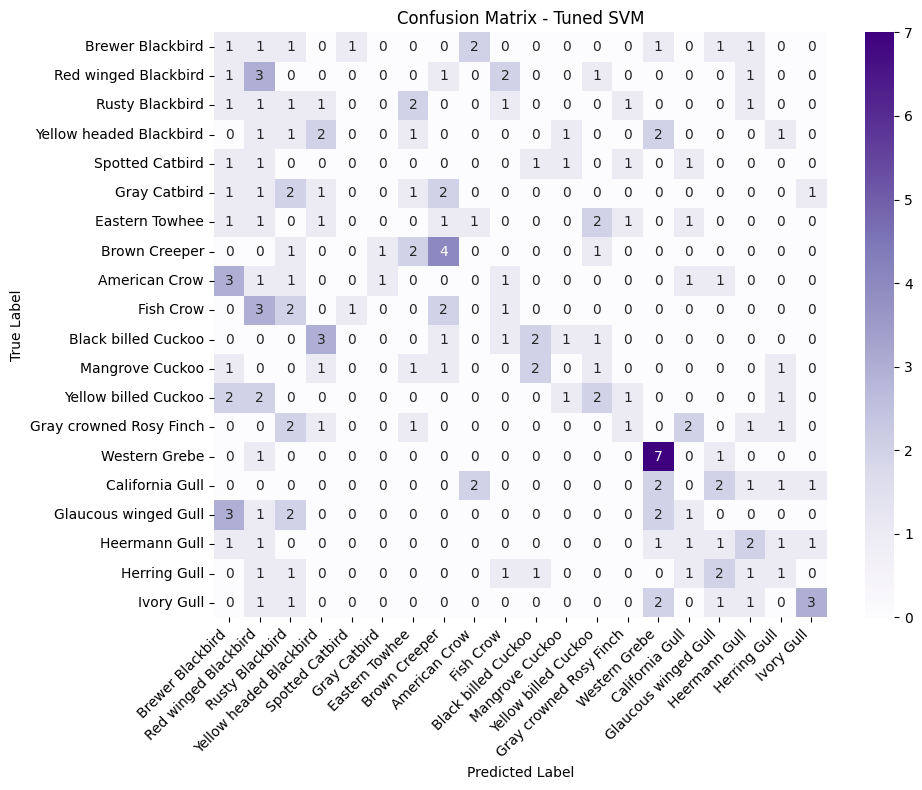

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

best_svm = grid_search_svm.best_estimator_
y_pred = best_svm.predict(X_test)
final_acc = accuracy_score(y_test, y_pred)
print(f"Final Tuned SVM Test Accuracy: {final_acc * 100:.2f}%")

# Save model
MODELS_DIR = Path("./models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)
model_path = MODELS_DIR / "svm_model.pkl"
joblib.dump(best_svm, model_path)
print(f"Best SVM model saved to '{model_path}' successfully!")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Tuned SVM')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##Evaluate SVM Model

In [6]:
import os
import joblib
from sklearn.metrics import accuracy_score

y_pred = best_svm.predict(X_test)

test_acc = accuracy_score(y_test, y_pred)
print("=" * 50)
print(f" FINAL TUNED SVM TEST ACCURACY: {test_acc * 100:.2f}%")
print("="* 50)

MODELS_DIR = "./models"
os.makedirs(MODELS_DIR, exist_ok=True)
model_path = os.path.join(MODELS_DIR, "svm_model.pkl")

joblib.dump(best_svm, model_path)
print(f"\nModel saved successfully to: '{model_path}'")

 FINAL TUNED SVM TEST ACCURACY: 17.05%

Model saved successfully to: './models/svm_model.pkl'
